In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [23]:
data = pd.read_csv('../data/modified_c4_epa_air_quality.csv')
data = data.dropna() # It is important to exclude NA from the analysis

In [24]:
data.info()

<class 'pandas.DataFrame'>
Index: 257 entries, 0 to 259
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date_local        257 non-null    str    
 1   state_name        257 non-null    str    
 2   county_name       257 non-null    str    
 3   city_name         257 non-null    str    
 4   local_site_name   257 non-null    str    
 5   parameter_name    257 non-null    str    
 6   units_of_measure  257 non-null    str    
 7   aqi_log           257 non-null    float64
dtypes: float64(1), str(7)
memory usage: 18.1 KB


In [25]:
data.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910
10,2018-01-01,Minnesota,Dakota,Rosemount,Flint Hills Refinery 420,Carbon monoxide,Parts per million,1.386294


The aqi_log column represents AQI readings that were transformed logarithmically to suit the objectives of this lab. Taking a logarithm of the aqi to get a bell-shaped distribution is outside the scope of this course, but is helpful to see the normal distribution.

<Axes: >

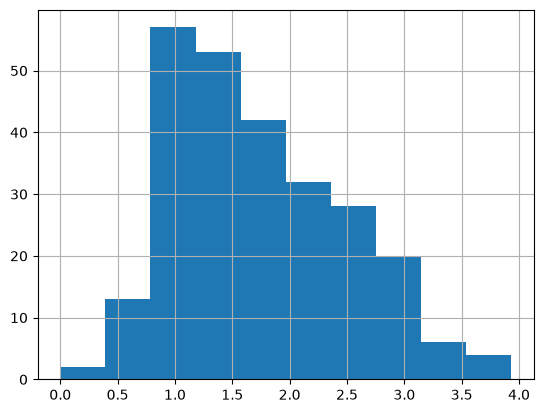

In [26]:
data['aqi_log'].hist()

Given the bell-shape of the distribution and histogram, the normal distribution could be a good fit modelling option for this dataset. To test use the Empirical rule. The rule states that for a given dataset with a normal distribution: 

- 68% of values fall within 1 standard deviation of the mean
    
- 95% of values fall within 2 standard deviations of the mean
    
- 99.7% of values fall within 3 standard deviations of the mean

In [27]:
mean_overall_li = data['aqi_log'].mean()
mean_overall_li

np.float64(1.7689182585091165)

In [28]:
std_overall_li = data['aqi_log'].std()
std_overall_li

np.float64(0.7164977499700741)

In [29]:
upper_limit = mean_overall_li + 1 * std_overall_li
lower_limit = mean_overall_li - 1 * std_overall_li

((data['aqi_log']>= lower_limit) & (data['aqi_log']<= upper_limit)).mean()

np.float64(0.7898832684824902)

In [30]:
upper_limit = mean_overall_li + 2 * std_overall_li
lower_limit = mean_overall_li - 2 * std_overall_li

((data['aqi_log']>= lower_limit) & (data['aqi_log']<= upper_limit)).mean()

np.float64(0.9571984435797666)

In [31]:
upper_limit = mean_overall_li + 3 * std_overall_li
lower_limit = mean_overall_li - 3 * std_overall_li

((data['aqi_log']>= lower_limit) & (data['aqi_log']<= upper_limit)).mean()

np.float64(0.9961089494163424)

Z-score calculation

In [32]:
data['zscore'] = stats.zscore(data['aqi_log'])
data

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log,zscore
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442,0.434236
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759,0.031941
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612,-0.937357
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294,-0.535062
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294,-0.535062
...,...,...,...,...,...,...,...,...,...
254,2018-01-01,Arizona,Pima,Tucson,CHERRY & GLENN,Carbon monoxide,Parts per million,2.708050,1.313283
255,2018-01-01,District Of Columbia,District of Columbia,Washington,Near Road,Carbon monoxide,Parts per million,1.386294,-0.535062
256,2018-01-01,Wisconsin,Dodge,Kekoskee,HORICON WILDLIFE AREA,Carbon monoxide,Parts per million,1.098612,-0.937357
257,2018-01-01,Kentucky,Jefferson,Louisville,CANNONS LANE,Carbon monoxide,Parts per million,1.098612,-0.937357


In [33]:
data[(data['zscore']>3)|(data['zscore']<-3)] 

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log,zscore
244,2018-01-01,Arizona,Maricopa,Phoenix,WEST PHOENIX,Carbon monoxide,Parts per million,3.931826,3.024612
